<h1>Skewness</h1>

skewness measures the asymmetry of your data's distrubution. Instead of perfectly balanced "bell curve", the data leans heavily to one side, stretching out into a long tail.

<h2>Types of skewness</h2>

- Postive(Right skewed): Tail streches to the right. Mean > Median
- Negative(Left skewed): Tail streches to the left. Mean < Median

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

Symmetric Distribution

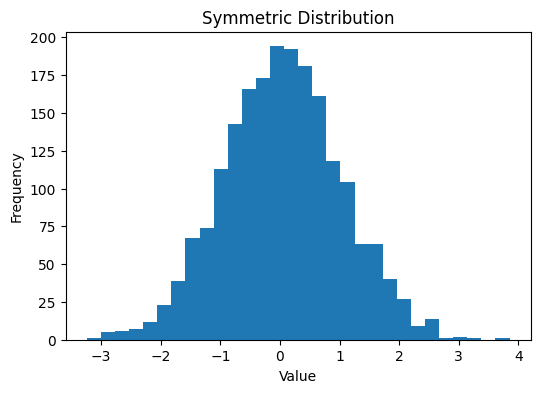

In [6]:
np.random.seed(42)

symmetric_data = np.random.normal(loc=0,scale=1,size=2000)

plt.figure(figsize=(6,4))
plt.hist(symmetric_data,bins=30)
plt.title("Symmetric Distribution")
plt.xlabel("Value")
plt.ylabel("Frequency")
plt.show()

In [7]:
np.mean(symmetric_data)

0.0450841465357407

In [8]:
np.median(symmetric_data)

0.04469165594146169

Left Skewed

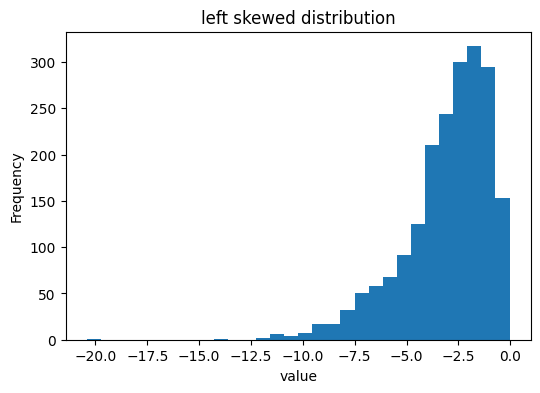

In [13]:
np.random.seed(42)

left_skewed = - np.random.gamma(shape=2.0 ,scale=1.5,size=2000)
plt.figure(figsize=(6,4))
plt.hist(left_skewed,bins=30)
plt.title("left skewed distribution")
plt.xlabel("value")
plt.ylabel("Frequency")
plt.show()

In [14]:
np.mean(left_skewed)

-3.069060756771498

In [15]:
np.median(left_skewed)

-2.592500305424706

Right skewed

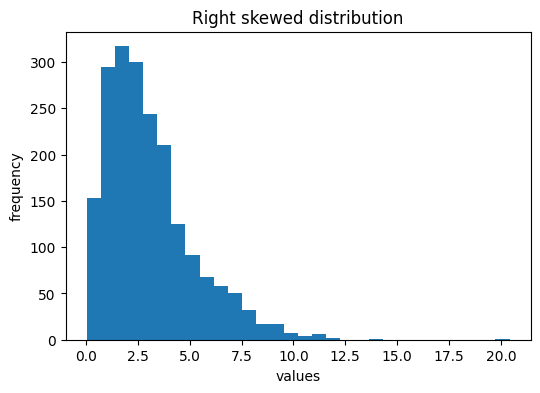

In [16]:
np.random.seed(42)
right_skewed = np.random.gamma(shape=2.0,scale=1.5,size=2000)
plt.figure(figsize=(6,4))
plt.hist(right_skewed,bins=30)
plt.title("Right skewed distribution")
plt.xlabel("values")
plt.ylabel("frequency")
plt.show()

In [17]:
np.mean(right_skewed)

3.069060756771498

In [18]:
np.median(right_skewed)

2.592500305424706

<h2>Right Skewed</h2>

If it is right skewed , we use log transformation

In [19]:
np.random.seed(42)

salary = np.random.exponential(scale=50000,size=1000)

df_pos = pd.DataFrame({"Salary":salary})

In [20]:
df_pos.head(10)

,Salary
0,23463.404499
1,150506.071546
2,65837.284677
3,45647.127689
4,8481.243523
5,8479.814596
6,2991.938430
7,100561.543224
8,45954.107681
9,61562.503085


In [21]:
import seaborn as sns

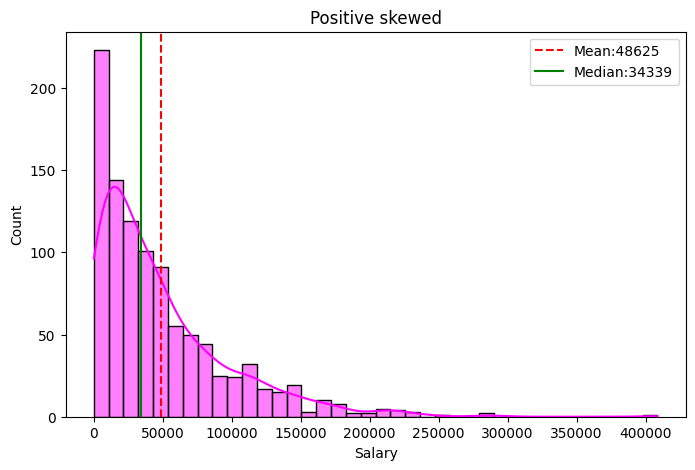

In [24]:
plt.figure(figsize=(8,5))
sns.histplot(df_pos['Salary'],kde=True,color='magenta')
mean_val = df_pos['Salary'].mean()
median_val = df_pos['Salary'].median()

plt.axvline(mean_val,color='red',linestyle='--',label=f"Mean:{mean_val:.0f}")
plt.axvline(median_val,color='green',linestyle='-',label=f"Median:{median_val:.0f}")

plt.title("Positive skewed")
plt.legend()

plt.show()

In [26]:
df_pos['log_salary'] = np.log1p(df_pos['Salary'])

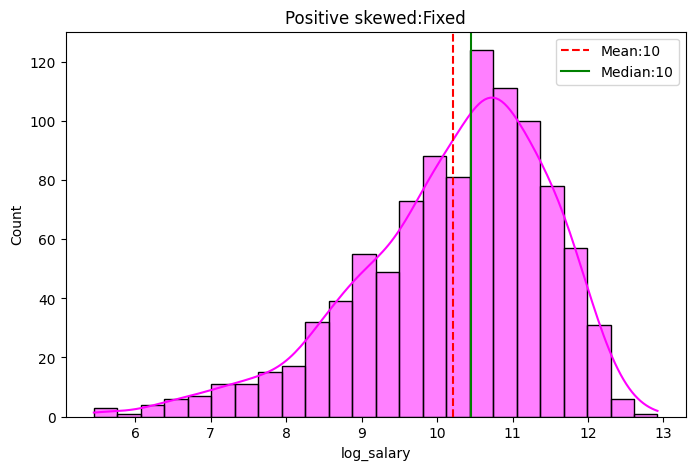

In [30]:
plt.figure(figsize=(8,5))
sns.histplot(df_pos['log_salary'],kde=True,color='magenta')
mean_val = df_pos['log_salary'].mean()
median_val = df_pos['log_salary'].median()

plt.axvline(mean_val,color='red',linestyle='--',label=f"Mean:{mean_val:.0f}")
plt.axvline(median_val,color='green',linestyle='-',label=f"Median:{median_val:.0f}")

plt.title("Positive skewed:Fixed")
plt.legend()

plt.show()

In [28]:
df_pos['log_salary']

0      10.063240
1      11.921765
2      11.094957
3      10.728718
4       9.045730
         ...    
995     8.477108
996    11.733153
997     8.903479
998    11.918561
999    10.293198
Name: log_salary, Length: 1000, dtype: float64

<h2>Left Skewed</h2>

In [39]:
scores = np.random.exponential(scale=15,size=1000)

df_neg = pd.DataFrame({
    'Score':scores
})

df_neg.head(10)

,Score
0,15.672815
1,2.838133
2,30.882185
3,14.244465
4,2.565453
5,49.186578
6,10.958545
7,1.135383
8,14.785935
9,4.379346


In [40]:
scores = 100 - np.random.exponential(scale=15,size=1000)

df_neg = pd.DataFrame({
    'Score':scores
})

df_neg.head(10)

,Score
0,99.406417
1,96.898834
2,73.310319
3,78.164153
4,93.523418
5,92.906427
6,88.560791
7,99.996384
8,95.858868
9,96.497701


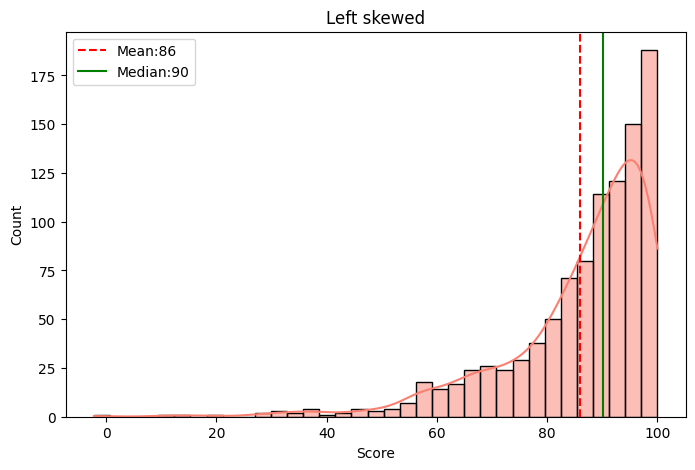

In [43]:
plt.figure(figsize=(8,5))
sns.histplot(df_neg['Score'],kde=True,color='salmon')
mean_val = df_neg['Score'].mean()
median_val = df_neg['Score'].median()

plt.axvline(mean_val,color='red',linestyle='--',label=f"Mean:{mean_val:.0f}")
plt.axvline(median_val,color='green',linestyle='-',label=f"Median:{median_val:.0f}")

plt.title("Left skewed")
plt.legend()

plt.show()

In [42]:
df_neg['Squared_score'] = np.square(df_neg['Score'])

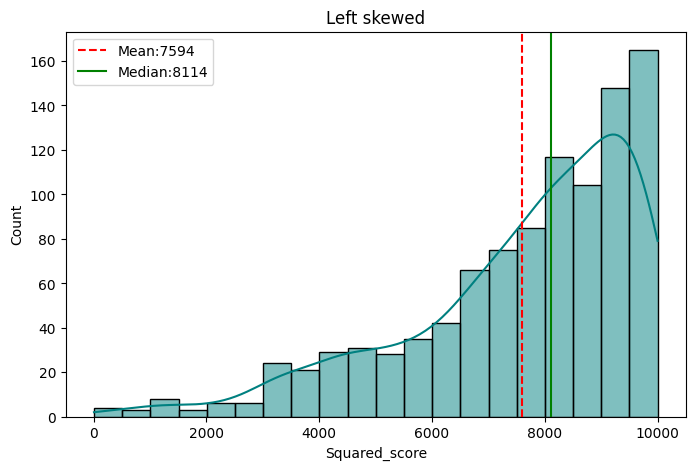

In [44]:
plt.figure(figsize=(8,5))
sns.histplot(df_neg['Squared_score'],kde=True,color='teal')
mean_val = df_neg['Squared_score'].mean()
median_val = df_neg['Squared_score'].median()

plt.axvline(mean_val,color='red',linestyle='--',label=f"Mean:{mean_val:.0f}")
plt.axvline(median_val,color='green',linestyle='-',label=f"Median:{median_val:.0f}")

plt.title("Left skewed")
plt.legend()

plt.show()

In [45]:
df_neg['Score'].skew()

-1.9143946596484347

In [46]:
df_pos['Salary'].skew()

1.867837146801098

In [47]:
df_pos['log_salary'].skew()


-0.8323581755168281

In [49]:
t = pd.DataFrame({"smd":symmetric_data})

In [50]:
t['smd'].skew()

0.0328790804092234

<h3>Numerical Detection</h3>

- -0.5 and 0.5: good to go
- -1 and -0.5/0.5: moderately skewed
- -1 or graeter than 1, highly skewed(transformation required)